# Практическая работа №6

**Цель работы:** изучить и сравнить методы искусственных нейронных сетей для решения задачи бинарной классификации на обработанном датасете. Оценить их эффективность, провести автоматический подбор гиперпараметров, сравнить результаты моделей до и после оптимизации.

**Задачи работы:**

1. Провести анализ и предобработку данных.
2. Реализовать и обучить первую нейронную сеть (SLP).
3. Реализовать и обучить вторую нейронную сеть (MLP).
4. Провести подбор гиперпараметров моделей с помощью Optuna.
5. Оценить модели по выбранным метрикам качества.
6. Сравнить результаты алгоритмов между собой, а также без и с использованием Optuna.
7. Построить графики обучения целевой функции.

**Используемые алгоритмы:**

1. **Single-Layer Perceptron (SLP):** однослойный перцептрон, самая простая нейронная сеть, которая состоит из входного слоя, одного линейного слоя, нелинейной функции активации (обычно sigmoid или ReLU). Реализует линейное разделение классов, поэтому работает хорошо, когда классы можно разделить прямой гиперплоскостью. Служит базовой моделью для сравнения с более сложными нейросетями. Основные параметры SLP: learning_rate — скорость обучения; optimizer — SGD, Adam; epochs — количество проходов по обучающей выборке; activation — функция активации; batch_size — размер мини-батча при обучении.

2. **Multi-Layer Perceptron (MLP):** многослойный перцептрон, расширение перцептрона, которое состоит из входного слоя, одного или нескольких скрытых слоёв, каждого со своей нелинейной активацией, и выходного слоя. Добавление скрытых слоёв позволяет сети моделировать сложные нелинейные зависимости, поэтому MLP значительно мощнее SLP. Хорошо работает для табличных данных, задач классификации и регрессии, случаев, когда нет пространственной структуры как у изображений. Ключевые параметры MLP: hidden_layers — количество скрытых слоёв; hidden_units — число нейронов в каждом скрытом слое; activation — ReLU, Tanh, Sigmoid; learning_rate — скорость обучения; optimizer — Adam/SGD; dropout — регуляризация; epochs и batch_size.

3. **Optuna:** библиотека для автоматического подбора гиперпараметров с использованием методов оптимизации на основе истории предыдущих экспериментов. Итеративно выбирает комбинации параметров, обучает модель и оценивает качество, стремясь минимизировать или максимизировать заданную метрику.

**Основные метрики:**

- **F1-score** для класса «дождь» — основная метрика, так как классы несбалансированы. Учитывает и precision, и recall.  
- **Accuracy** — общая оценка, но второстепенная при дисбалансе.

Датасет (из 1 работы): https://www.kaggle.com/datasets/jsphyg/weather-dataset-rattle-package/data

In [ ]:
# Используемые библиотеки
!pip install optuna
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam, SGD
from sklearn.metrics import accuracy_score, f1_score, classification_report
import matplotlib.pyplot as plt
import optuna
from sklearn.model_selection import train_test_split

## 1. Загрузка и анализ данных

Ранее для данного датасета Rain in Australia была проведена полная предобработка данных: обработаны пропуски, удалены выбросы, категориальные признаки преобразованы с помощью One-Hot Encoding, удалены ненужные и сильно коррелированные признаки, дата преобразована в числовой формат. Данные разделены на обучающую (train), валидационную (valid) и тестовую (test) выборки. Нейронная сеть чувствительна к масштабу данных, данные ранее уже стандартизированы.

,Rainfall,Sunshine,WindGustSpeed,Humidity9am,Humidity3pm,Pressure9am,Cloud3pm,Temp3pm,RainToday,Location_Albany,...,Location_WaggaWagga,Location_Walpole,Location_Watsonia,Location_Williamtown,Location_Witchcliffe,Location_Wollongong,Location_Woomera,Year,Month,Day
10832,2.540517,-2.830020,0.769071,1.221947,0.511072,0.926395,1.028669,-0.780448,1,False,...,False,False,False,False,False,False,False,2011,6,13
64426,5.047411,0.173575,1.301877,0.272726,0.024543,-1.297080,0.719060,-0.083081,1,False,...,False,False,False,False,False,False,False,2017,1,17
61488,-0.279738,1.850000,0.236264,-1.098371,-0.559292,-0.911678,-0.828984,0.730514,0,False,...,False,False,False,False,False,False,False,2015,1,1
81810,-0.279738,-0.769414,0.084034,0.483664,1.484131,0.600286,1.028669,-1.448758,0,False,...,False,False,False,False,False,False,False,2013,6,16
70346,0.612137,-0.420159,-0.068197,1.274681,1.143560,0.363115,0.099843,-0.649691,1,False,...,False,False,False,False,False,False,False,2012,8,4


,RainTomorrow
10832,1
64426,1
61488,0
81810,1
70346,1


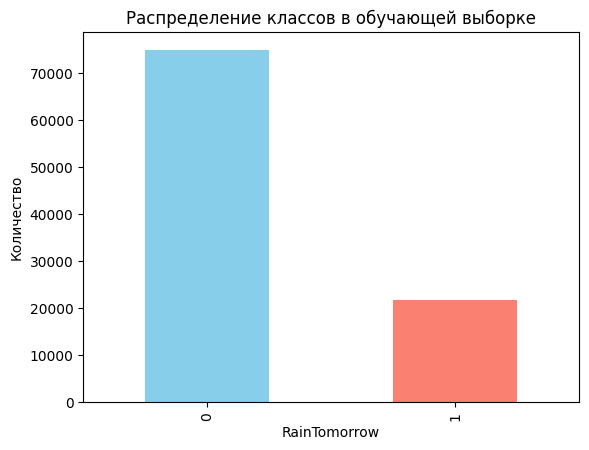

In [ ]:
# Загрузка обработанных данных
!wget -q https://github.com/GusevaVarvara/Weather-dataset/raw/main/train_reduced.pkl
!wget -q https://github.com/GusevaVarvara/Weather-dataset/raw/main/val_reduced.pkl
!wget -q https://github.com/GusevaVarvara/Weather-dataset/raw/main/test_reduced.pkl

X_train, y_train = joblib.load("train_reduced.pkl")
X_val, y_val = joblib.load("val_reduced.pkl")
X_test, y_test = joblib.load("test_reduced.pkl")

display(X_train.head())
display(y_train.head())

# Распределение целевого признака
pd.Series(y_train).value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title("Распределение классов в обучающей выборке")
plt.xlabel("RainTomorrow")
plt.ylabel("Количество")
plt.show()

Видно, что наблюдается дисбаланс классов, поэтому при оценке качества моделей важно учитывать не только Accuracy, но и F1-score.

## 2. Single-Layer Perceptron (SLP)

Будем использовать Keras (TensorFlow), там есть встроенная модель Sequential для построения SLP и MLP моделей.

SLP будет состоять из:
- одного полносвязного (`Linear`) слоя размера `input_dim 1`,
- функции активации Sigmoid, чтобы вывести вероятность класса «дождь»,
- оптимизатора Adam и функции потерь `BCELoss` стандартной для бинарной классификации.

Обучим модель на train, контролируем качество на валидации. Также построим график, где будут представлены кривые изменения функции потерь на обучении и валидации.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7520 - loss: 25.3798 - val_accuracy: 0.8323 - val_loss: 0.3808
Epoch 2/20
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8303 - loss: 0.3846 - val_accuracy: 0.8245 - val_loss: 0.4064
Epoch 3/20
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8360 - loss: 0.3787 - val_accuracy: 0.8249 - val_loss: 0.3929
Epoch 4/20
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8327 - loss: 0.3848 - val_accuracy: 0.8231 - val_loss: 0.3952
Epoch 5/20
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8373 - loss: 0.3761 - val_accuracy: 0.8205 - val_loss: 0.4365
Epoch 6/20
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8379 - loss: 0.3757 - val_accuracy: 0.8376 - val_loss: 0.3728
Epoch 7/20
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8352 - loss: 0.3793 - val_accuracy: 0.8115 - val_loss: 0.4135
Epoch 8/20
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8352 - loss: 0.3796 -

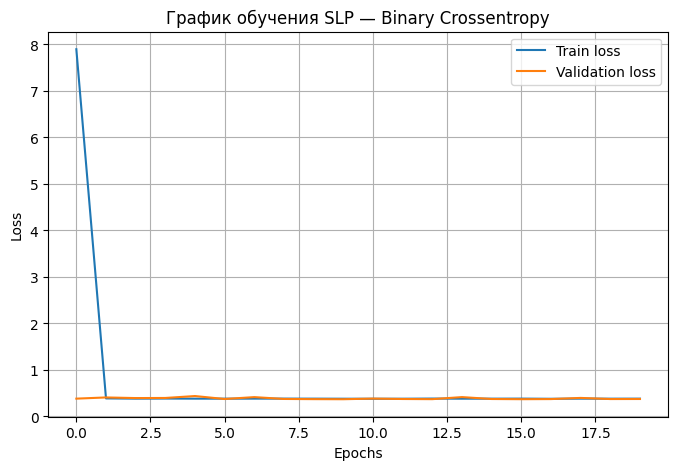

In [ ]:
# Модель SLP
slp_model = Sequential([
    Dense(1, activation='sigmoid', input_dim=X_train.shape[1])
])

slp_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Обучение
history_slp = slp_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=64,
    verbose=1
)

y_val_pred_slp = (slp_model.predict(X_val) >= 0.5).astype(int)
y_test_pred_slp = (slp_model.predict(X_test) >= 0.5).astype(int)

# Метрики
print("Validation:")
print("Accuracy:", accuracy_score(y_val, y_val_pred_slp))
print("F1-score:", f1_score(y_val, y_val_pred_slp))
print(classification_report(y_val, y_val_pred_slp))

print("\nTest:")
print("Accuracy:", accuracy_score(y_test, y_test_pred_slp))
print("F1-score:", f1_score(y_test, y_test_pred_slp))
print(classification_report(y_test, y_test_pred_slp))

# График обучения
plt.figure(figsize=(8, 5))
plt.plot(history_slp.history['loss'], label='Train loss')
plt.plot(history_slp.history['val_loss'], label='Validation loss')
plt.title("График обучения SLP — Binary Crossentropy")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()

Основная метрика — F1-score класса 1 (RainTomorrow = 1), так как класс несбалансирован.
На валидации:
- Accuracy = 0.8375
- F1 = 0.606
- Recall = 0.56, сеть пропускает часть случаев дождя.
- Precision = 0.66, часть предсказанных дождей — ложные.

На тесте результаты аналогичны:
- Accuracy = 0.841
- F1 = 0.612

На графике целевой функции можно наблюдать характерное поведение для модели с ограниченной сложностью: Train loss начинает с большого значения, затем резко падает и стабилизируется; Validation loss с самого начала находится в адекватном диапазоне и также остаётся стабильным на протяжении обучения. Это связано с тем, что первые эпохи веса сети ещё случайные, а train_loss вычисляется по мини-батчам, где возможны «сложные» батчи. Между train и val loss нет большого разрыва, что означает отсутствие серьёзного переобучения.

После нескольких эпох значение функции потерь перестаёт уменьшаться, линии на графике становятся почти горизонтальными, что говорит о том, что SLP достиг максимума своих возможностей. Loss около 0.37, это не идеально, но для SLP ожидаемо, так как однослойный перцептрон может моделировать только линейные зависимости.

Однослойный перцептрон показывает стабильные, но ограниченные результаты. Он эффективно обучается и не переобучается. Его F1-score находится на хорошом уровне 0.60–0.61 (и приблизительно самом высоком, который показывали другие модели на этих данных).

## 3. Multi-Layer Perceptron (MLP)


Добавление скрытых слоёв позволяет сети моделировать сложные нелинейные зависимости. В этой модели:
- используем 2 скрытых слоя по 64 нейрона с активацией ReLU,
- используем Adam и binary crossentropy как функцию потерь,

Будем отслеживать целевую функцию на train и validation и построим график изменения loss, чтобы визуально оценить процесс обучения.


Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1511/1511 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7435 - loss: 4.8889 - val_accuracy: 0.7896 - val_loss: 0.8295
Epoch 2/20
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7912 - loss: 0.5753 - val_accuracy: 0.6044 - val_loss: 0.8619
Epoch 3/20
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8017 - loss: 0.5229 - val_accuracy: 0.8336 - val_loss: 0.4320
Epoch 4/20
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8053 - loss: 0.5118 - val_accuracy: 0.8004 - val_loss: 0.6583
Epoch 5/20
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8035 - loss: 0.5103 - val_accuracy: 0.7988 - val_loss: 0.6476
Epoch 6/20
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8023 - loss: 0.5114 - val_accuracy: 0.7966 - val_loss: 0.4466
Epoch 7/20
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8153 - loss: 0.4456 - val_accuracy: 0.8303 - val_loss: 0.3847
Epoch 8/20
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8170 - loss: 0.4419 - val_accurac

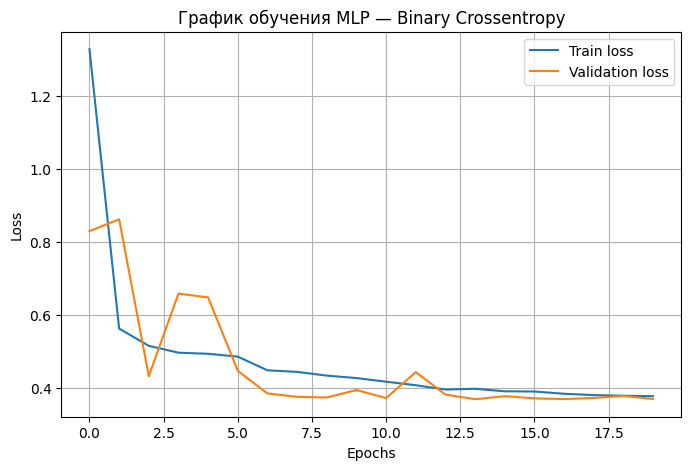

In [ ]:
# Модель MLP
mlp_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

mlp_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Обучение
history_mlp = mlp_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=64,
    class_weight={0:1, 1:4},
    verbose=1
)

y_val_pred_mlp = (mlp_model.predict(X_val) >= 0.5).astype(int)
y_test_pred_mlp = (mlp_model.predict(X_test) >= 0.5).astype(int)

# Метрики
print("Validation:")
print("Accuracy:", accuracy_score(y_val, y_val_pred_mlp))
print("F1-score:", f1_score(y_val, y_val_pred_mlp))
print(classification_report(y_val, y_val_pred_mlp))

print("\nTest:")
print("Accuracy:", accuracy_score(y_test, y_test_pred_mlp))
print("F1-score:", f1_score(y_test, y_test_pred_mlp))
print(classification_report(y_test, y_test_pred_mlp))

# График обучения
plt.figure(figsize=(8, 5))
plt.plot(history_mlp.history['loss'], label='Train loss')
plt.plot(history_mlp.history['val_loss'], label='Validation loss')
plt.title("График обучения MLP — Binary Crossentropy")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()

Accuracy высокий (0.84), но F1-score класса 1 падает по сравнению с SLP (с 0.61 до 0.57). Вероятная причина в несбалансированных классах, сеть может игнорировать редкий класс, оптимизируя общую loss, что и видно по F1.

График обучения: Train loss постепенно спадает, почти плавно, достигая примерно 0.37 к концу обучения; Validation loss скачет и менее стабильна. Это может быть связано с шумом в данных и дисбалансом классов. Класс 1 составляет примерно 20–25% выборки, поэтому отдельные батчи могут быть менее репрезентативны и вызывать колебания loss. В итоге модель обучается и сходится, loss снижается, но дисбаланс делает кривую валидации менее ровной.

MLP имеет больше параметров, может теоретически лучше моделировать нелинейные зависимости. Но без явного учёта дисбаланса оптимизация ориентируется на общий loss. В целом модель обучилась нормально, loss снизился, но для редкого класса нужно применять балансировку.

## 4. Optuna

Используем Optuna для поиска наилучших гиперпараметров для моделей. Она будет искать комбинации, которые максимизируют F1-score.

### SLP

Возьмём 30% обучающей выборки, чтобы ускорить обучение. Основные гиперпараметры для SLP: learning rate, optimizer, batch_size, activation и class_weight для класса 1, чтобы сеть лучше ловила редкий класс.

In [ ]:
# Для ускорения берем часть данных
X_train_sample, _, y_train_sample, _ = train_test_split(
    X_train, y_train, train_size=0.3, stratify=y_train, random_state=42
)

# Функция для Optuna
def objective_slp(trial):
    # гиперпараметры
    lr = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    optimizer_name = trial.suggest_categorical('optimizer', ['adam', 'sgd'])
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128])
    activation = trial.suggest_categorical('activation', ['sigmoid', 'relu'])
    class_weight_1 = trial.suggest_float("class_weight_1", 1.0, 5.0)
    class_weight = {0: 1.0, 1: class_weight_1}


    # выбор оптимизатора
    optimizer = Adam(learning_rate=lr) if optimizer_name=='adam' else SGD(learning_rate=lr)

    # создаём SLP
    model = Sequential([
        Dense(1, activation=activation, input_shape=(X_train_sample.shape[1],))
    ])
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

    # обучение
    model.fit(
        X_train_sample, y_train_sample,
        validation_split=0.2,
        epochs=10,
        batch_size=batch_size,
        verbose=0,
        class_weight=class_weight
    )

    y_val_pred = (model.predict(X_val) >= 0.5).astype(int)
    f1 = f1_score(y_val, y_val_pred)
    return f1

# Запуск Optuna
study_slp = optuna.create_study(direction='maximize')
study_slp.optimize(objective_slp, n_trials=15)

print("Лучшие параметры SLP:", study_slp.best_params)
print("Лучший F1 на валидации:", study_slp.best_value)

[I 2025-11-18 13:23:45,686] A new study created in memory with name: no-name-a0b1b252-853a-44ce-a6e3-c9ba21cf3cbf
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


756/756 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step  


[I 2025-11-18 13:23:56,224] Trial 0 finished with value: 0.36624763449580966 and parameters: {'learning_rate': 0.003158302131800489, 'optimizer': 'adam', 'batch_size': 64, 'activation': 'relu', 'class_weight_1': 2.3542890836855555}. Best is trial 0 with value: 0.36624763449580966.
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


756/756 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


[I 2025-11-18 13:24:03,459] Trial 1 finished with value: 0.36624763449580966 and parameters: {'learning_rate': 0.008132024243978131, 'optimizer': 'sgd', 'batch_size': 128, 'activation': 'sigmoid', 'class_weight_1': 1.2805142392486237}. Best is trial 0 with value: 0.36624763449580966.
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

756/756 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


[I 2025-11-18 13:27:23,754] Trial 13 finished with value: 0.3008903899293829 and parameters: {'learning_rate': 0.005842190255063672, 'optimizer': 'adam', 'batch_size': 32, 'activation': 'sigmoid', 'class_weight_1': 1.5913518767201564}. Best is trial 11 with value: 0.6132730502179881.
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


756/756 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


[I 2025-11-18 13:27:48,717] Trial 14 finished with value: 0.5721758624984431 and parameters: {'learning_rate': 0.0009418309300268917, 'optimizer': 'adam', 'batch_size': 32, 'activation': 'sigmoid', 'class_weight_1': 3.5961947262393403}. Best is trial 11 with value: 0.6132730502179881.


Лучшие параметры SLP: {'learning_rate': 0.0016687147456857577, 'optimizer': 'adam', 'batch_size': 32, 'activation': 'sigmoid', 'class_weight_1': 3.591234102230797}
Лучший F1 на валидации: 0.6132730502179881


Обучим SLP на полных данных с лучшими параметрами из Optuna.

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3022/3022 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.7066 - loss: 17.1306 - val_accuracy: 0.7018 - val_loss: 0.6051
Epoch 2/20
3022/3022 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.7492 - loss: 0.8200 - val_accuracy: 0.8041 - val_loss: 0.4281
Epoch 3/20
3022/3022 ━━━━━━━━━━━━━━━━━━━━ 13s 4ms/step - accuracy: 0.7503 - loss: 0.8233 - val_accuracy: 0.7439 - val_loss: 0.5336
Epoch 4/20
3022/3022 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.7486 - loss: 0.8228 - val_accuracy: 0.5601 - val_loss: 0.8783
Epoch 5/20
3022/3022 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.7537 - loss: 0.8098 - val_accuracy: 0.7851 - val_loss: 0.4619
Epoch 6/20
3022/3022 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.7521 - loss: 0.8119 - val_accuracy: 0.8007 - val_loss: 0.4324
Epoch 7/20
3022/3022 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.7489 - loss: 0.8203 - val_accuracy: 0.7829 - val_loss: 0.4667
Epoch 8/20
3022/3022 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.7496 - loss: 0.8290 - val_accu

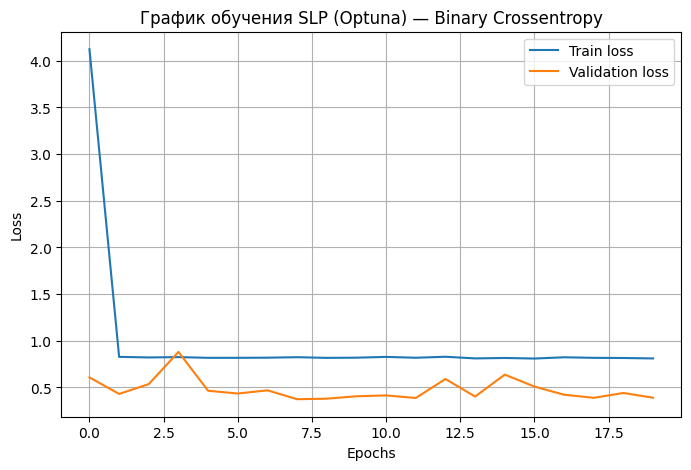

In [ ]:
# Оптимальные параметры
best_params_slp = {
    'learning_rate': 0.0016687147456857577,
    'optimizer': 'adam',
    'batch_size': 32,
    'activation': 'sigmoid',
    'class_weight_1': 3.591234102230797
}
class_weight = {0: 1.0, 1: best_params_slp['class_weight_1']}

# Оптимизатор
optimizer = Adam(learning_rate=best_params_slp['learning_rate'])

# Модель SLP
slp_model_opt = Sequential([
    Dense(1, activation=best_params_slp['activation'], input_shape=(X_train.shape[1],))
])

slp_model_opt.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Обучение
history_slp_opt = slp_model_opt.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=best_params_slp['batch_size'],
    class_weight=class_weight,
    verbose=1
)

y_val_pred_slp_opt = (slp_model_opt.predict(X_val) >= 0.5).astype(int)
y_test_pred_slp_opt = (slp_model_opt.predict(X_test) >= 0.5).astype(int)

# Метрики
print("Validation:")
print("Accuracy:", accuracy_score(y_val, y_val_pred_slp_opt))
print("F1-score:", f1_score(y_val, y_val_pred_slp_opt))
print(classification_report(y_val, y_val_pred_slp_opt))

print("\nTest:")
print("Accuracy:", accuracy_score(y_test, y_test_pred_slp_opt))
print("F1-score:", f1_score(y_test, y_test_pred_slp_opt))
print(classification_report(y_test, y_test_pred_slp_opt))

# График обучения
plt.figure(figsize=(8, 5))
plt.plot(history_slp_opt.history['loss'], label='Train loss')
plt.plot(history_slp_opt.history['val_loss'], label='Validation loss')
plt.title("График обучения SLP (Optuna) — Binary Crossentropy")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()

График обучения: train loss примерно такой же, модель быстро достигла своего максимума на тренировочных данных; validation loss теперь колеблется, но в целом держится на низком уровне, модель стала лучше работать с редким классом, благодаря class_weight.

F1 для класса 1 вырос с 0.61 (без Optuna) до 0.62–0.63 на тесте. Accuracy немного снизилась на тесте (0.83 вместо 0.84), что ожидаемо, так как class_weight усилил редкий класс. В целом баланс между Precision и Recall улучшился для класса 1.

Оптимизация гиперпараметров и добавление class_weight позволили улучшить F1-score для редкого класса, что важно при дисбалансе. SLP всё ещё ограничен линейными зависимостями, но улучшен.

### MLP

Возьмём также 30% обучающей выборки, чтобы ускорить обучение. Основные гиперпараметры для MLP: n_layers, n_units, learning rate, optimizer, batch_size и class_weight.

In [ ]:
# Для ускорения берем часть данных
X_train_sample, _, y_train_sample, _ = train_test_split(
    X_train, y_train, train_size=0.3, stratify=y_train, random_state=42
)

# Функция для Optuna
def objective_mlp(trial):
    # гиперпараметры
    n_layers = trial.suggest_int('n_layers', 1, 3)
    n_units = trial.suggest_int('n_units', 32, 128, step=32)
    lr = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    optimizer_name = trial.suggest_categorical('optimizer', ['adam', 'sgd'])
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128])
    class_weight_1 = trial.suggest_float("class_weight_1", 1.0, 5.0)
    class_weight = {0: 1.0, 1: class_weight_1}

    # выбор оптимизатора
    optimizer = Adam(learning_rate=lr) if optimizer_name=='adam' else SGD(learning_rate=lr)

    # создаём MLP
    model = Sequential()
    model.add(Dense(n_units, activation='relu', input_shape=(X_train_sample.shape[1],)))
    for _ in range(n_layers-1):
        model.add(Dense(n_units, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

    # обучение
    model.fit(
        X_train_sample, y_train_sample,
        validation_split=0.2,
        epochs=10,
        batch_size=batch_size,
        verbose=0,
        class_weight=class_weight
    )

    y_val_pred = (model.predict(X_val) >= 0.5).astype(int)
    f1 = f1_score(y_val, y_val_pred)
    return f1

# Запуск Optuna
study_mlp = optuna.create_study(direction='maximize')
study_mlp.optimize(objective_mlp, n_trials=15)

print("Лучшие параметры MLP (без dropout):", study_mlp.best_params)
print("Лучший F1 на валидации:", study_mlp.best_value)


[I 2025-11-18 14:11:00,771] A new study created in memory with name: no-name-71678376-bcb6-4ab8-8ed2-9afdc0c1474a
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


756/756 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step


[I 2025-11-18 14:11:12,879] Trial 0 finished with value: 0.0 and parameters: {'n_layers': 3, 'n_units': 64, 'learning_rate': 0.001452962643964723, 'optimizer': 'sgd', 'batch_size': 128, 'class_weight_1': 2.0064228280807597}. Best is trial 0 with value: 0.0.
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


756/756 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


[I 2025-11-18 14:11:23,657] Trial 1 finished with value: 0.0 and parameters: {'n_layers': 3, 'n_units': 32, 'learning_rate': 0.0002035607309812072, 'optimizer': 'sgd', 'batch_size': 128, 'class_weight_1': 1.6286669420859452}. Best is trial 0 with value: 0.0.
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

756/756 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


[I 2025-11-18 14:14:19,470] Trial 13 finished with value: 0.4730226437355357 and parameters: {'n_layers': 1, 'n_units': 128, 'learning_rate': 0.0030050831705052453, 'optimizer': 'adam', 'batch_size': 64, 'class_weight_1': 2.562318902965326}. Best is trial 10 with value: 0.6147859922178989.
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


756/756 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


[I 2025-11-18 14:14:35,138] Trial 14 finished with value: 0.5455570590888588 and parameters: {'n_layers': 2, 'n_units': 128, 'learning_rate': 0.003310089918601647, 'optimizer': 'adam', 'batch_size': 64, 'class_weight_1': 3.490617788692577}. Best is trial 10 with value: 0.6147859922178989.


Лучшие параметры MLP (без dropout): {'n_layers': 1, 'n_units': 128, 'learning_rate': 0.009057600255361642, 'optimizer': 'adam', 'batch_size': 64, 'class_weight_1': 3.233407464115346}
Лучший F1 на валидации: 0.6147859922178989


Обучим MLP на полных данных с лучшими параметрами из Optuna.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.6650 - loss: 9.1447 - val_accuracy: 0.6108 - val_loss: 0.9701
Epoch 2/20
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7141 - loss: 1.2284 - val_accuracy: 0.7115 - val_loss: 0.6076
Epoch 3/20
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7460 - loss: 0.8502 - val_accuracy: 0.7884 - val_loss: 0.4598
Epoch 4/20
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7721 - loss: 0.7435 - val_accuracy: 0.8004 - val_loss: 0.4384
Epoch 5/20
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7786 - loss: 0.7263 - val_accuracy: 0.7941 - val_loss: 0.4482
Epoch 6/20
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7753 - loss: 0.7378 - val_accuracy: 0.5912 - val_loss: 0.7846
Epoch 7/20
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7705 - loss: 0.7432 - val_accuracy: 0.7936 - val_loss: 0.4341
Epoch 8/20
1511/1511 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7692 - loss: 0.7469 - 

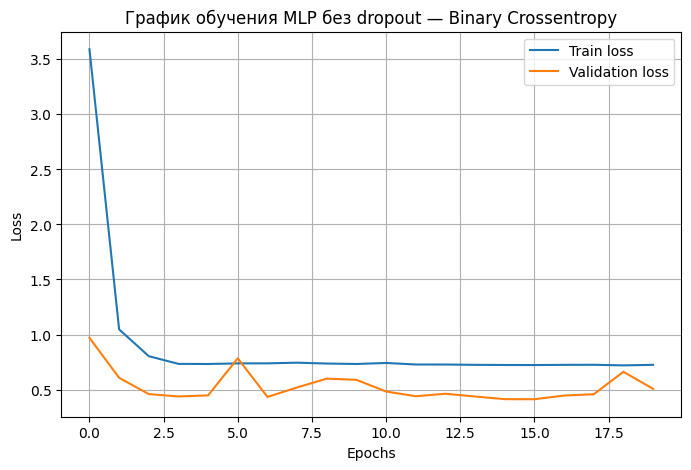

In [ ]:
# Оптимизированные параметры
best_params_mlp_no_dropout = {
    'n_layers': 1,
    'n_units': 128,
    'learning_rate': 0.009057600255361642,
    'optimizer': 'adam',
    'batch_size': 64,
    'class_weight_1': 3.233407464115346
}

class_weight = {0: 1, 1: best_params_mlp_no_dropout['class_weight_1']}

# Создание модели
mlp_model = Sequential()
mlp_model.add(Dense(best_params_mlp_no_dropout['n_units'], activation='relu', input_shape=(X_train.shape[1],)))
for _ in range(best_params_mlp_no_dropout['n_layers'] - 1):
    mlp_model.add(Dense(best_params_mlp_no_dropout['n_units'], activation='relu'))
mlp_model.add(Dense(1, activation='sigmoid'))

# Компиляция модели
mlp_model.compile(
    optimizer=Adam(learning_rate=best_params_mlp_no_dropout['learning_rate']),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Обучение
history_mlp = mlp_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=best_params_mlp_no_dropout['batch_size'],
    class_weight=class_weight,
    verbose=1
)

y_val_pred_mlp = (mlp_model.predict(X_val) >= 0.5).astype(int)
y_test_pred_mlp = (mlp_model.predict(X_test) >= 0.5).astype(int)

# Метрики
print("Validation:")
print("Accuracy:", accuracy_score(y_val, y_val_pred_mlp))
print("F1-score:", f1_score(y_val, y_val_pred_mlp))
print(classification_report(y_val, y_val_pred_mlp))

print("\nTest:")
print("Accuracy:", accuracy_score(y_test, y_test_pred_mlp))
print("F1-score:", f1_score(y_test, y_test_pred_mlp))
print(classification_report(y_test, y_test_pred_mlp))

# График обучения
plt.figure(figsize=(8, 5))
plt.plot(history_mlp.history['loss'], label='Train loss')
plt.plot(history_mlp.history['val_loss'], label='Validation loss')
plt.title("График обучения MLP без dropout — Binary Crossentropy")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()

MLP с помощью Optuna даёт более стабильное F1 по редкому классу: F1-score по классу 1 стал выше (0.61 на тесте с 0.56-0.57), но снизилась Accuracy (0.76 с 0.84).

График обучения стал разумнее: обе линии (train и val loss) находятся примерно на одном уровне, валидационная потеря колеблется по низу, но меньше. Модель не переобучается и лучше учитывает меньший класс.

## Вывод

1. Однослойный перцептрон (SLP)

Базовое обучение: Accuracy была достаточно высокой (0.84), но F1 мера по редкому классу (0.61) показала, что модель справляется с главным классом, но меньше внимания уделяет редкому классу.

После Optuna: F1 на валидации немного вырос (до 0.63), график обучения стал чуть более логичным. Accuracy осталась примерно на том же уровне, совсем немного снизилась.

2. Многоуровневый перцептрон (MLP)

Базовое обучение: Accuracy немного выше базового SLP (0.84), F1 по редкому классу ниже, около 0.57.

После Optuna: F1 по редкому классу улучшился (0.60–0.61), график обучения стал более «чистым» и логичным. Accuracy при этом стала ниже, около 0.76–0.77.

3. Сравнение моделей

Хотя MLP в целом умеет моделировать нелинейные зависимости, в этой задаче она не дала явного преимущества, а точность упала сильнее, чем у SLP. SLP после Optuna показала лучший баланс между точностью и F1, при этом обе метрики высокие и стабильно сбалансированы. Поэтому для этих данных лучше всего подходит SLP после оптимизации гиперпараметров с помощью Optuna: она проще, быстрее обучается и обеспечивает наилучшие показатели F1 без существенной потери точности.

**Итог:** сравнили два подхода для классификации данных — однослойный перцептрон (SLP) и многослойный перцептрон (MLP), применили Optuna для подбора оптимальных гиперпараметров моделей. После оптимизации SLP показал лучший баланс между точностью и F1. Определили, что для этих данных оптимальная модель — однослойный перцептрон после подбора гиперпараметров.
